In [58]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf


## 1) Model du CAPM:  

$$E(R_i) = R_f + \beta_{i}(E(R_m)-R_f)$$
$$\beta_{i} = \dfrac{Cov(R_i;R_m)}{Var(R_m)}$$

Où:  
$R_f$: taux sans risque (ex: obligation d'état, bon du trésor)  
$R_m$: représente le rendement de l'ensemble du marché (ou d'un indice de marché représentatif)  
$\beta$: rémuneration structuelle  




In [59]:
# calcule du beta ainsi que des parametres : 
def Cov(X, Y):
    return np.mean((X - np.mean(X)) * (Y - np.mean(Y)))
def Var(X):
    return np.mean((X - np.mean(X)) ** 2)
def Beta(X, Y):
    return Cov(X, Y) / Var(X)



In [60]:
pf = yf.download(["AAPL", "URTH"], start='2020-01-01')['Close'].pct_change().dropna()
pf_beta = Beta(pf["AAPL"], pf["URTH"])
print("Beta de Apple par rapport à l'indice MSCI World : ", pf_beta)

C:\Users\Tom\AppData\Local\Temp\ipykernel_3732\731787032.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  pf = yf.download(["AAPL", "URTH"], start='2020-01-01')['Close'].pct_change().dropna()
[*********************100%***********************]  2 of 2 completed

Beta de Apple par rapport à l'indice MSCI World :  0.46741055909079077


Text(0, 0.5, 'Rendement AAPL')

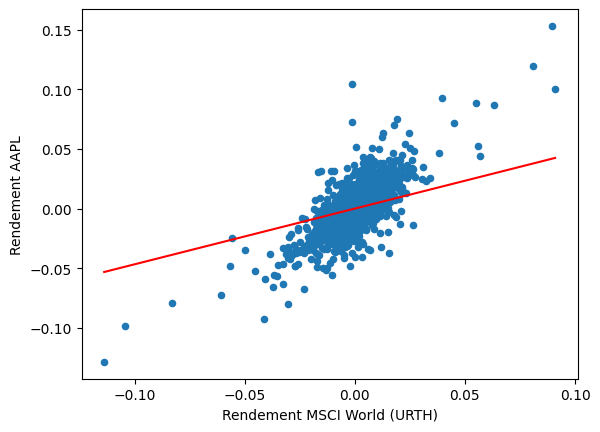

In [61]:
pf.plot.scatter(x='URTH', y='AAPL')
x_line = np.linspace(pf['URTH'].min(), pf['URTH'].max(), 1000)
y_line = pf_beta * x_line
plt.plot(x_line, y_line, color='red', label='Ligne de régression')
plt.xlabel('Rendement MSCI World (URTH)')
plt.ylabel('Rendement AAPL')

calcule de $E(R_m)$ avec la Prime de risque historique + taux sans risque  

$E(R_m) = R_f + prime\ de\ risque\ historique $  

avec :  
$prime\ de\ risque\ historique = \dfrac{1}{T} \Sigma (R_{m,t} - R_{f,t}) $
